## Principal Component Analysis, Condition number and least squares  

In [268]:
import numpy as np 
import matplotlib.pyplot as plt 

# Loading data from the dat file obtained from PCE
Cd_data = np.loadtxt('pce_uq_results.dat', skiprows=1, usecols=range(5, 1204))
Cl_data = np.loadtxt('pce_uq_results.dat', skiprows=1, usecols=range(1205, 2404))
# The first four columns are eval_id, interface, x1, x2 
param_viscosity = np.loadtxt('pce_uq_results.dat', skiprows=1, usecols=2)
param_density = np.loadtxt('pce_uq_results.dat', skiprows=1, usecols=3)
# # making the data from each analysis a column vector
Cd_data = Cd_data.T
Cl_data = Cl_data.T

# printing the data to see what it looks like
print(Cd_data.shape)
print(Cl_data.shape)
# print(param_viscosity)
# print(param_density)

(1199, 100)
(1199, 100)


### Centering the data to calculate variance

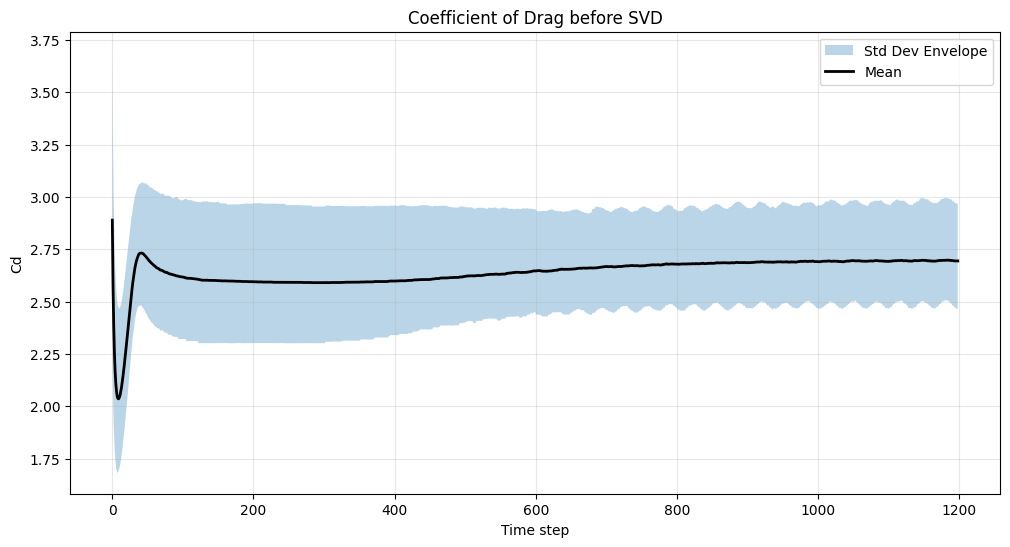

In [269]:
# Select the data for centering for PCA
time_len = 1199

data = Cd_data  # select Cl_data or Cd_data
data_mean = data.mean(axis=1, keepdims=True)
data_centered = data - data_mean
data_std = data.std(axis=1, keepdims=True)
data_min = data.min(axis=1)
data_max = data.max(axis=1)

# Plotting the data before SVD
plt.figure(figsize=(12, 6))
plt.fill_between(range(time_len), data_min, data_max, alpha=0.3, label='Std Dev Envelope')
plt.plot(data_mean, 'k-', linewidth=2, label='Mean')
if data is Cd_data:
    plt.xlabel('Time step')
    plt.ylabel('Cd')
    plt.title('Coefficient of Drag before SVD')
else:
    plt.xlabel('Time step')
    plt.ylabel('Cl')
    plt.title('Coefficient of Lift before SVD')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

### Calculating the SVD

Text(0, 0.5, 'singular values')

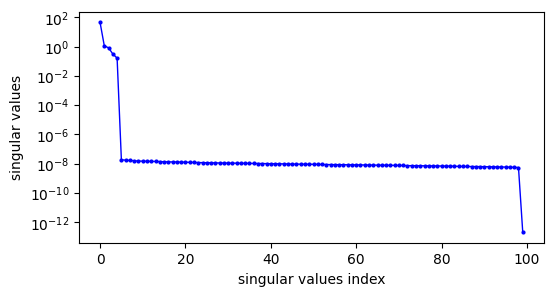

In [270]:
U,S,Vt = np.linalg.svd(data_centered, full_matrices=False)

plt.figure(figsize = (6,3))
plt.semilogy(S, 'bo-', linewidth=1, markersize= 2)
plt.xlabel('singular values index')
plt.ylabel('singular values')

In [271]:
# Condition number
# cond_number = S[0] / S[-1]
cond_number = np.linalg.cond(data_centered)
print(f'Condition number of the data matrix: {cond_number:.2e}')
print(f'maximum singular value, minimum singular value: {S[0]}, {S[-1]}')
if cond_number > 1e6:
    print("The data matrix is ill-conditioned.")
else:
    print("The data matrix is well-conditioned.")

Condition number of the data matrix: 2.22e+14
maximum singular value, minimum singular value: 45.84555366743522, 2.063597297214133e-13
The data matrix is ill-conditioned.


The data matrix is well-conditioned for:
Rank   1: kappa_r = 1.00e+00
Rank   2: kappa_r = 4.09e+01
Rank   3: kappa_r = 5.60e+01
Rank   4: kappa_r = 1.49e+02
Rank   5: kappa_r = 2.83e+02


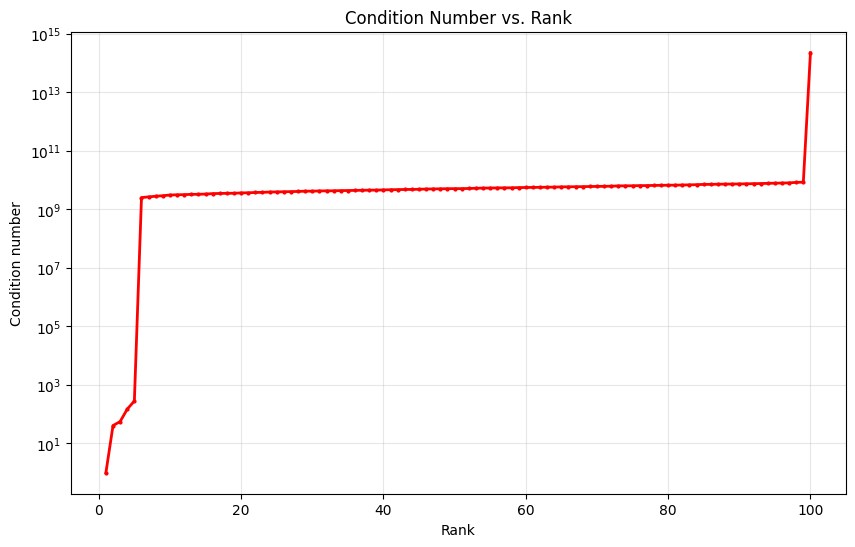

In [272]:
# condition number vs rank 
ranks = range(1, len(S)+1, 1)
condition_numbers = []
print(f"The data matrix is well-conditioned for:")
for r in ranks:
    kappa_r = S[0] / S[r-1]
    condition_numbers.append(kappa_r)
    if kappa_r < 1e6:
        print(f"Rank {r:3d}: kappa_r = {kappa_r:.2e}")
    
# Plot
plt.figure(figsize=(10, 6))
plt.semilogy(ranks, condition_numbers, 'ro-', markersize=2, linewidth=2)
plt.xlabel('Rank')
plt.ylabel('Condition number')
plt.title('Condition Number vs. Rank')
plt.grid(True, alpha=0.3)
plt.show()

### Ill-conditioned systems vs well-conditioned system 

In [273]:
# Problem: Predict Cd at a specific time from modal coefficients
time_idx = 1000  

# Matrix with 100 rank r
r_full = 100
A_full = Vt[:r_full, :].T  # Shape: (100, 100)
kappa_full = S[0] / S[r_full-1]

r_low = 5
A_low = Vt[:r_low, :].T  # Shape: (100, 5)
kappa_low = S[0] / S[r_low-1]

print(f"  Full-rank (r={r_full}): kappa_{r_full} = {kappa_full:.2e}")
print(f"  Low-rank  (r={r_low}):  kappa_{r_low} = {kappa_low:.2e}")
print(f"  Low-rank has {kappa_full/kappa_low:.0f} times better conditioning!")

  Full-rank (r=100): kappa_100 = 2.22e+14
  Low-rank  (r=5):  kappa_5 = 2.83e+02
  Low-rank has 786333733847 times better conditioning!


In [274]:
# Solving the prediction problem with out the noise using least squares (PINV)
# Right-hand side b: Cd values at selected time
b_true = data_centered[time_idx, :]

# Clean solutions
# Full-rank solution
x_full_clean = np.linalg.pinv(A_full) @ b_true
error_full_clean = np.linalg.norm(A_full @ x_full_clean - b_true) / np.linalg.norm(b_true)

# Low-rank solution
x_low_clean = np.linalg.pinv(A_low) @ b_true
error_low_clean = np.linalg.norm(A_low @ x_low_clean - b_true) / np.linalg.norm(b_true)

print(f"\nWithout noise:")
print(f"  Full-rank fitting error: {error_full_clean:.2e}")
print(f"  Low-rank fitting error:  {error_low_clean:.2e}")


Without noise:
  Full-rank fitting error: 5.77e-16
  Low-rank fitting error:  2.31e-09


In [275]:
noise = 1e-10 # very small noise 
b_noisy = b_true + noise * np.random.randn(*b_true.shape)

# Noisy solutions
# Full-rank solution
x_full_noisy = np.linalg.pinv(A_full) @ b_noisy
error_full_noisy = np.linalg.norm(A_full @ x_full_noisy - b_true) / np.linalg.norm(b_true)
# Low-rank solution
x_low_noisy = np.linalg.pinv(A_low) @ b_noisy
error_low_noisy = np.linalg.norm(A_low @ x_low_noisy - b_true) / np.linalg.norm(b_true)

print(f"\nWith noise (noise level: {noise}):")
print(f"  Full-rank fitting error: {error_full_noisy:.2e}")
print(f"  Low-rank fitting error:  {error_low_noisy:.2e}")


With noise (noise level: 1e-10):
  Full-rank fitting error: 8.60e-10
  Low-rank fitting error:  2.31e-09


### PCA of the data

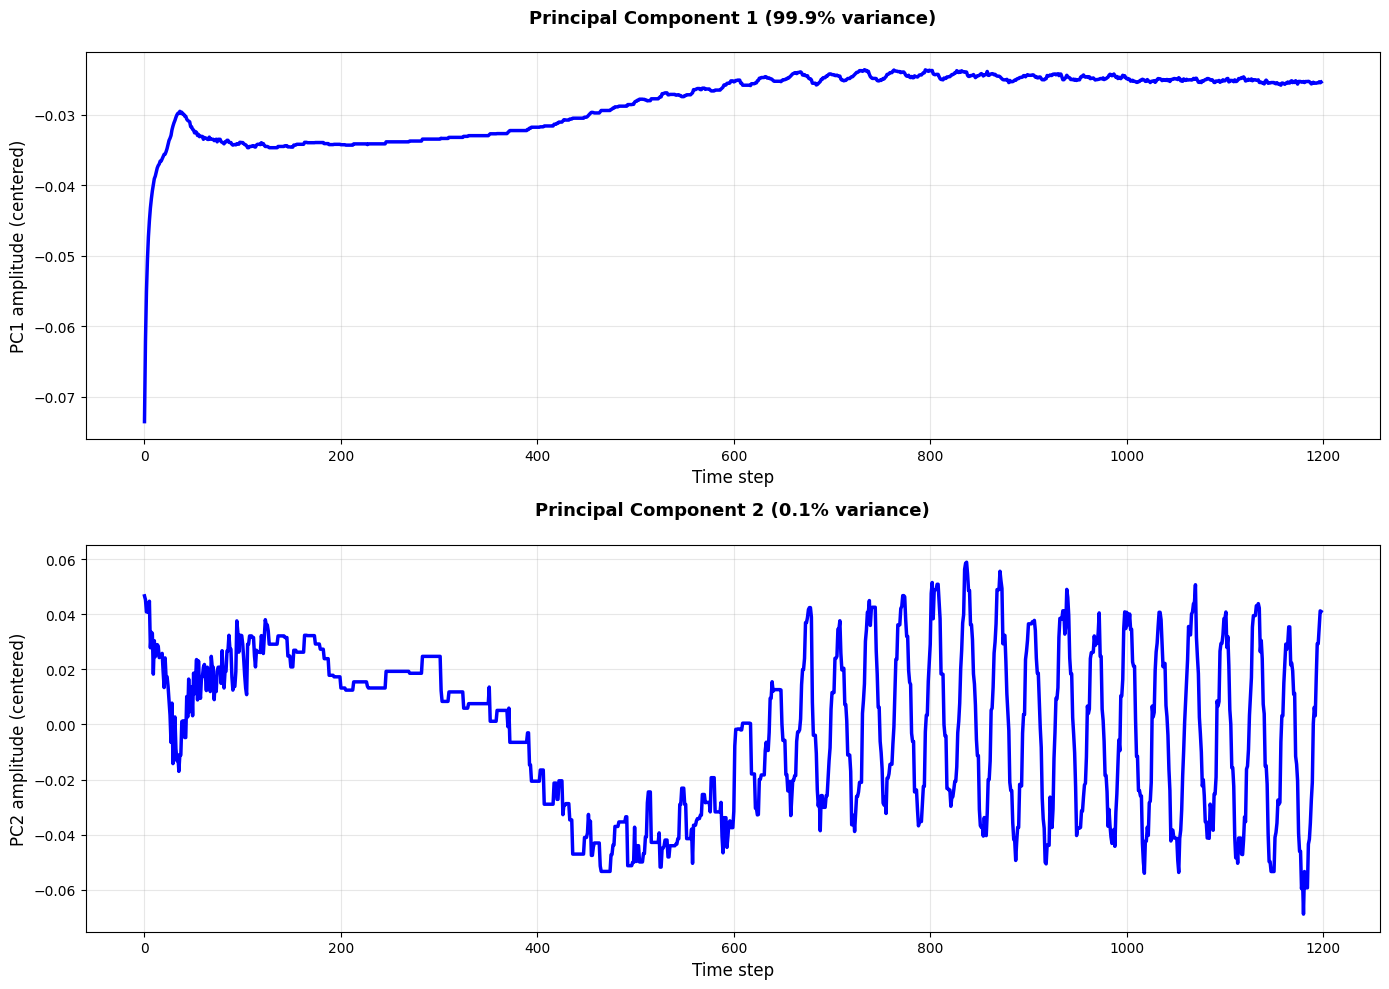

In [276]:
# We already have the SVD of the data loaded as U, S, Vt on the centered data 
# Calculate variance
variance = S**2 / np.sum(S**2)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i in range(2):
    ax = axes[i]
    # Plot eigenmode
    ax.plot(U[:, i], 'b-', linewidth=2.5)
    ax.set_title(f'Principal Component {i+1} ({100*variance[i]:.1f}% variance)\n',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Time step', fontsize=12)
    ax.set_ylabel(f'PC{i+1} amplitude (centered)', fontsize=12)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Sample 2 reconstruction:
  Original Cd mean:     2.64
  Reconstructed mean:   2.66


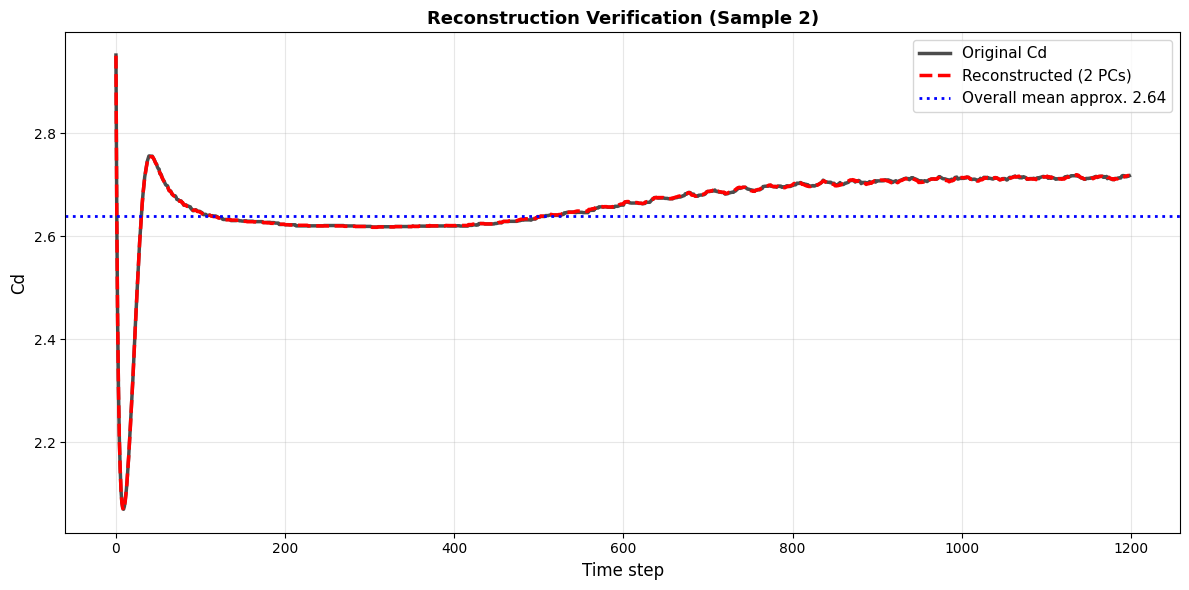

In [277]:
# Pick a sample to reconstruct
sample_idx = 2

# Reconstruct using first 2 modes
mean_profile = Cd_data.mean(axis=1)
coefficients = S[:2] * Vt[:2, sample_idx]
reconstructed = mean_profile + U[:, :2] @ coefficients

print(f"\nSample {sample_idx} reconstruction:")
print(f"  Original Cd mean:     {Cd_data.mean():.2f}")
print(f"  Reconstructed mean:   {reconstructed.mean():.2f}")

# Plot verification
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(Cd_data[:, sample_idx], 'k-', linewidth=2.5, alpha=0.7, label='Original Cd')
ax.plot(reconstructed, 'r--', linewidth=2.5, label='Reconstructed (2 PCs)')
ax.axhline(Cd_data.mean(), color='blue', linestyle=':', linewidth=2, 
          label=f'Overall mean approx. {Cd_data.mean():.2f}')
ax.set_xlabel('Time step', fontsize=12)
ax.set_ylabel('Cd', fontsize=12)
ax.set_title(f'Reconstruction Verification (Sample {sample_idx})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

